In [1]:
#imports 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
df=pd.read_csv("MBA.csv")
print(df.index)
print("All columns are")
ai=0
for i in df:
    print(ai,i)
    ai+=1

RangeIndex(start=0, stop=6194, step=1)
All columns are
0 application_id
1 gender
2 international
3 gpa
4 major
5 race
6 gmat
7 work_exp
8 work_industry
9 admission


In [3]:
df.shape

(6194, 10)

In [4]:
df.head()

,application_id,gender,international,gpa,major,race,gmat,work_exp,work_industry,admission
0,1,Female,False,3.30,Business,Asian,620.0,3.0,Financial Services,Admit
1,2,Male,False,3.28,Humanities,Black,680.0,5.0,Investment Management,NaN
2,3,Female,True,3.30,Business,NaN,710.0,5.0,Technology,Admit
3,4,Male,False,3.47,STEM,Black,690.0,6.0,Technology,NaN
4,5,Male,False,3.35,STEM,Hispanic,590.0,5.0,Consulting,NaN


In [5]:
df.sample(n=10)

,application_id,gender,international,gpa,major,race,gmat,work_exp,work_industry,admission
1988,1989,Female,False,3.43,Humanities,White,720.0,7.0,Consulting,Admit
5903,5904,Male,True,3.06,STEM,NaN,680.0,4.0,Consulting,NaN
511,512,Female,True,3.47,Business,NaN,650.0,4.0,Investment Banking,Admit
1193,1194,Male,False,3.02,Humanities,Black,590.0,4.0,Nonprofit/Gov,NaN
4206,4207,Female,True,3.07,Business,NaN,630.0,5.0,Consulting,NaN
627,628,Male,False,3.18,Business,Hispanic,570.0,5.0,Health Care,NaN
1632,1633,Male,False,2.82,Humanities,Black,570.0,6.0,Technology,NaN
2488,2489,Female,False,3.12,STEM,White,670.0,7.0,Consulting,NaN
5494,5495,Female,True,3.17,Business,NaN,650.0,5.0,Real Estate,NaN
59,60,Male,False,3.41,Humanities,White,740.0,4.0,Financial Services,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6194 entries, 0 to 6193
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   application_id  6194 non-null   int64  
 1   gender          6194 non-null   object 
 2   international   6194 non-null   bool   
 3   gpa             6194 non-null   float64
 4   major           6194 non-null   object 
 5   race            4352 non-null   object 
 6   gmat            6194 non-null   float64
 7   work_exp        6194 non-null   float64
 8   work_industry   6194 non-null   object 
 9   admission       1000 non-null   object 
dtypes: bool(1), float64(3), int64(1), object(5)
memory usage: 441.7+ KB


In [7]:
df.isnull()

,application_id,gender,international,gpa,major,race,gmat,work_exp,work_industry,admission
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,True,False,False,False,False
3,False,False,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...
6189,False,False,False,False,False,False,False,False,False,True
6190,False,False,False,False,False,False,False,False,False,True
6191,False,False,False,False,False,True,False,False,False,False
6192,False,False,False,False,False,True,False,False,False,True


In [8]:
print(df.isnull().sum())
print("Race and admission have null values")

application_id       0
gender               0
international        0
gpa                  0
major                0
race              1842
gmat                 0
work_exp             0
work_industry        0
admission         5194
dtype: int64
Race and admission have null values


In [9]:
df.describe()

,application_id,gpa,gmat,work_exp
count,6194.000000,6194.000000,6194.000000,6194.000000
mean,3097.500000,3.250714,651.092993,5.016952
std,1788.198115,0.151541,49.294883,1.032432
min,1.000000,2.650000,570.000000,1.000000
25%,1549.250000,3.150000,610.000000,4.000000
50%,3097.500000,3.250000,650.000000,5.000000
75%,4645.750000,3.350000,680.000000,6.000000
max,6194.000000,3.770000,780.000000,9.000000


In [10]:
df.columns

Index(['application_id', 'gender', 'international', 'gpa', 'major', 'race',
       'gmat', 'work_exp', 'work_industry', 'admission'],
      dtype='object')

In [11]:
# function for calculating which product occur multiple times and how much time it occur
def duplicates(column_name):
    counts = df[column_name].value_counts()
    duplicates = counts[counts > 1]
    result = duplicates.reset_index()
    result.columns = [column_name, 'Count']
    print(result)

duplicates("gender")
print()
duplicates("international")
print()
duplicates("major")
print()
duplicates("race")
print()
duplicates("work_exp")
print()
duplicates("work_industry")
print()
duplicates("admission")

   gender  Count
0    Male   3943
1  Female   2251

   international  Count
0          False   4352
1           True   1842

        major  Count
0  Humanities   2481
1        STEM   1875
2    Business   1838

       race  Count
0     White   1456
1     Asian   1147
2     Black    916
3  Hispanic    596
4     Other    237

   work_exp  Count
0       5.0   2419
1       6.0   1528
2       4.0   1437
3       3.0    369
4       7.0    367
5       8.0     38
6       2.0     32
7       9.0      2
8       1.0      2

            work_industry  Count
0              Consulting   1619
1                   PE/VC    907
2              Technology    716
3           Nonprofit/Gov    651
4      Investment Banking    580
5      Financial Services    451
6                   Other    421
7             Health Care    334
8   Investment Management    166
9                     CPG    114
10            Real Estate    111
11    Media/Entertainment     59
12                 Retail     33
13                 Ene

In [15]:
# lets impute missing values with something

# Filling missing race with unknown
df["race"] = df["race"].fillna("Unknown")



# Filling missing admission value with Rejected
df["admission"] = df["admission"].fillna("Rejected")

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6194 entries, 0 to 6193
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   application_id  6194 non-null   int64  
 1   gender          6194 non-null   object 
 2   international   6194 non-null   bool   
 3   gpa             6194 non-null   float64
 4   major           6194 non-null   object 
 5   race            6194 non-null   object 
 6   gmat            6194 non-null   float64
 7   work_exp        6194 non-null   float64
 8   work_industry   6194 non-null   object 
 9   admission       6194 non-null   object 
dtypes: bool(1), float64(3), int64(1), object(5)
memory usage: 441.7+ KB


In [25]:
# Function that can return all rows of a specified value
def getrows(column_name, value):
    return df[df[column_name] == value]
a = getrows('admission','Admit')
b = getrows('admission','Waitlist')
c = getrows('admission','Rejected')

In [26]:
a.describe()

,application_id,gpa,gmat,work_exp
count,900.000000,900.000000,900.000000,900.000000
mean,2684.390000,3.354867,692.733333,5.046667
std,1908.907688,0.126637,40.495760,1.007226
min,1.000000,2.890000,570.000000,1.000000
25%,840.250000,3.270000,670.000000,4.000000
50%,2591.500000,3.350000,690.000000,5.000000
75%,4318.250000,3.430000,720.000000,6.000000
max,6192.000000,3.740000,780.000000,8.000000


In [27]:
b.describe()

,application_id,gpa,gmat,work_exp
count,100.000000,100.0000,100.00000,100.000000
mean,2226.990000,3.3135,673.60000,4.910000
std,1879.332831,0.1325,40.08879,0.985706
min,13.000000,2.9000,580.00000,3.000000
25%,715.250000,3.2400,640.00000,4.000000
50%,1087.000000,3.3200,670.00000,5.000000
75%,3747.750000,3.4100,700.00000,6.000000
max,6089.000000,3.6500,780.00000,7.000000


In [28]:
c.describe()

,application_id,gpa,gmat,work_exp
count,5194.000000,5194.000000,5194.000000,5194.000000
mean,3185.842318,3.231457,643.444359,5.013862
std,1750.222364,0.148152,47.059665,1.037614
min,2.000000,2.650000,570.000000,1.000000
25%,1690.250000,3.130000,610.000000,4.000000
50%,3200.500000,3.230000,640.000000,5.000000
75%,4700.750000,3.330000,670.000000,6.000000
max,6194.000000,3.770000,780.000000,9.000000


In [34]:
print('''After analyzing the people who got Admit , Waitlist and Rejected the results are

            Average gpa       Average gmat
            
Admit        3.354867	       692.733333  	

Waitlist     3.3135            673.60000

Rejected     3.231457	       643.444359

We can clearly see that the deciding factor is gmat score

''')

After analyzing the people who got Admit , Waitlist and Rejected the results are

            Average gpa       Average gmat

Admit        3.354867	       692.733333  	

Waitlist     3.3135            673.60000

Rejected     3.231457	       643.444359

We can clearly see that the deciding factor is gmat score




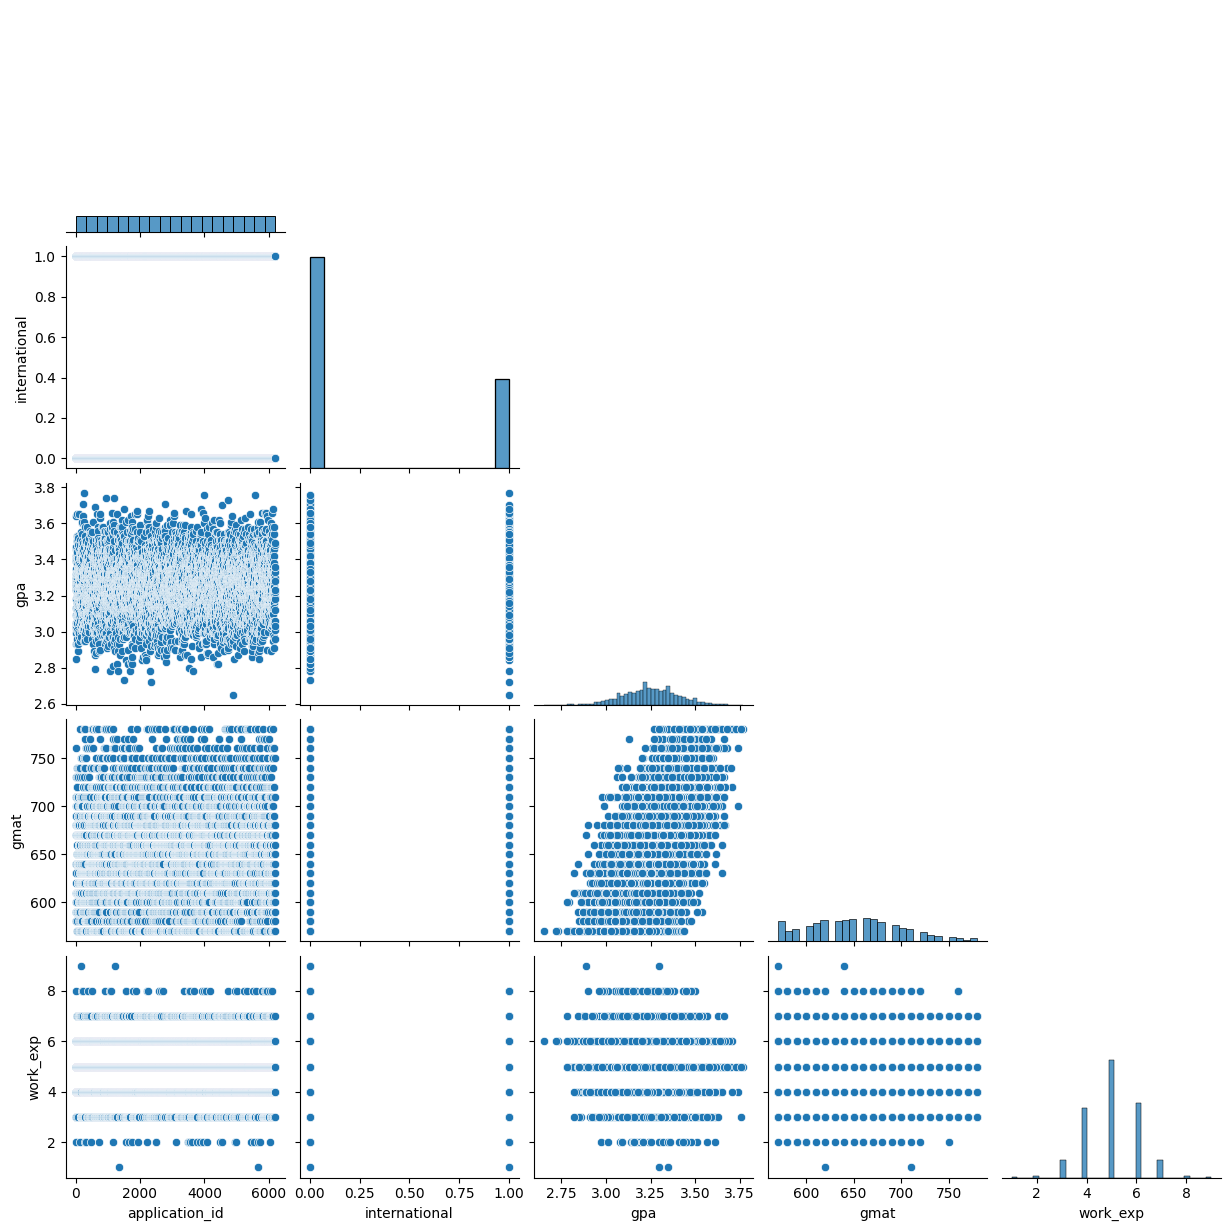

In [35]:
grid = sns.pairplot(df,corner=True)

In [38]:
# For saving the plot
'''

grid.savefig('MBApairplot.png', dpi=300, bbox_inches='tight')

'''
print('This plot gives us a rough idea of the data')

This plot gives us a rough idea of the data


In [36]:
df.columns

Index(['application_id', 'gender', 'international', 'gpa', 'major', 'race',
       'gmat', 'work_exp', 'work_industry', 'admission'],
      dtype='object')

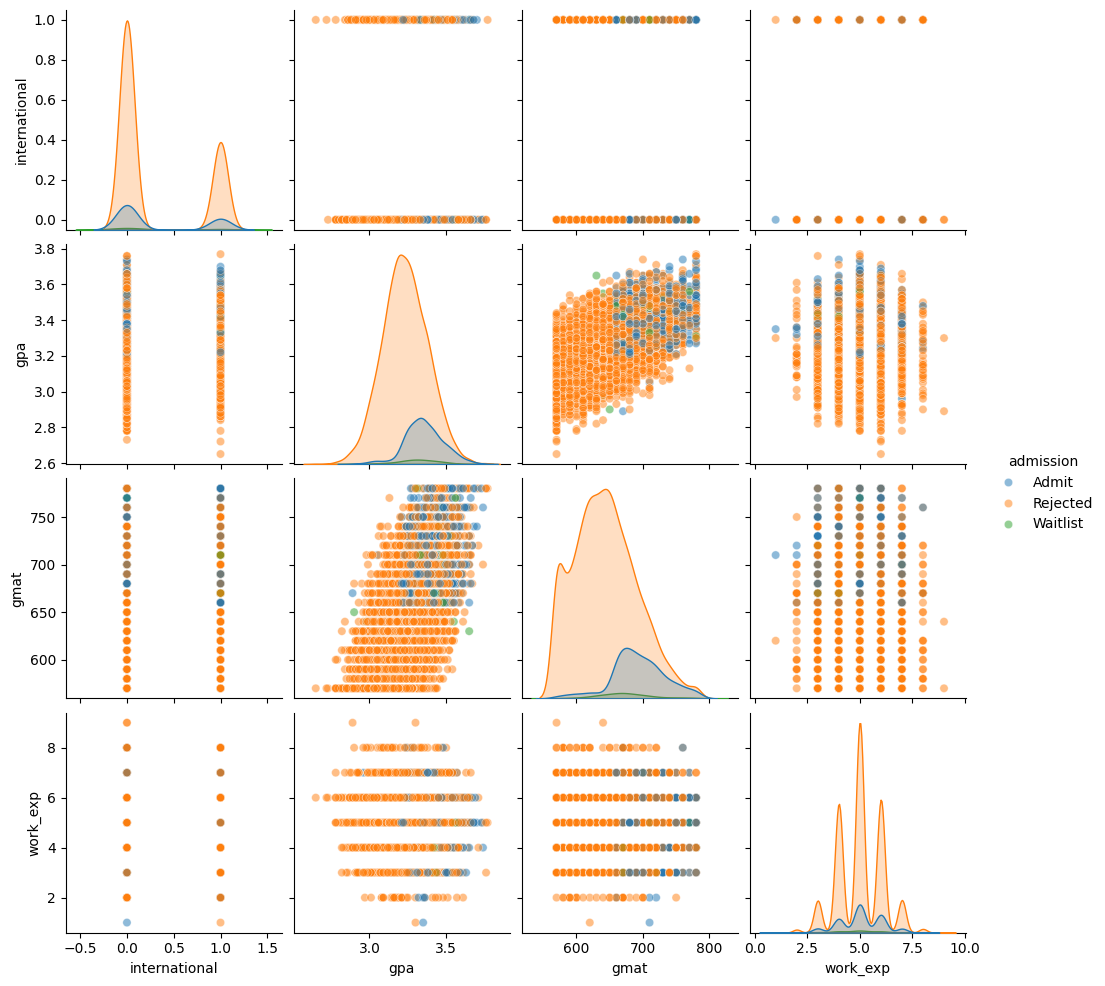

In [37]:
churnplot = sns.pairplot(
            df,
            vars=['international', 'gpa','gmat', 'work_exp'],
            hue='admission',
            plot_kws={'alpha':0.5}
            )

In [39]:
'''

churnplot.savefig('MBApairplotchurn.png', dpi=300, bbox_inches='tight')

'''

<Axes: >

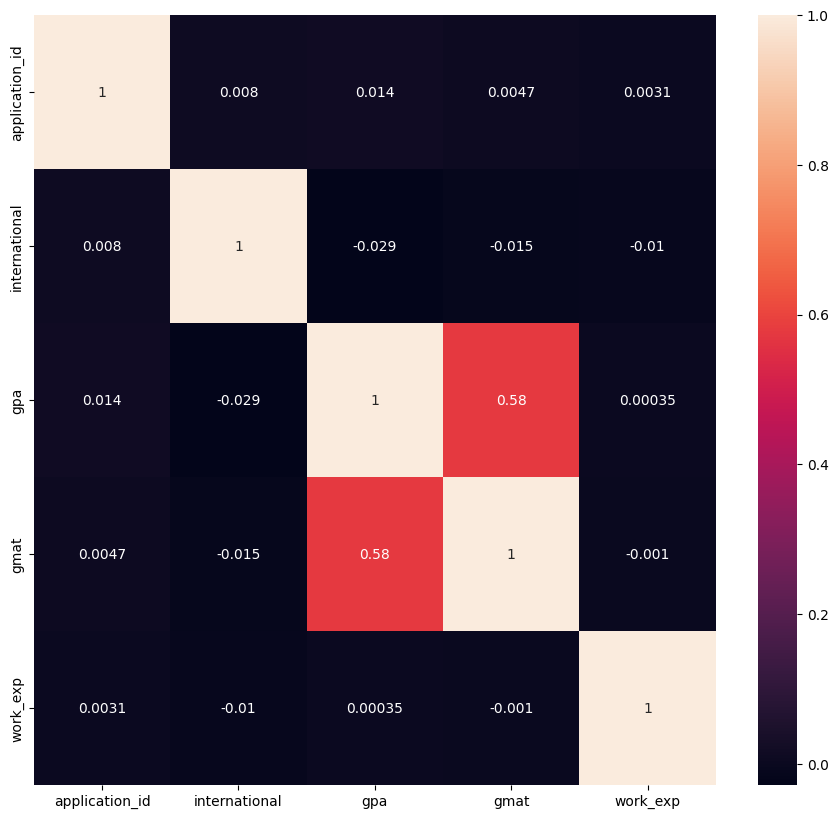

In [40]:
plt.figure(figsize=(11,10))
sns.heatmap(df.corr(numeric_only=True),annot=True)